In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#load dataset
df=pd.read_csv('Android_Ransomeware.csv')
df.head(10)

,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,172.217.2.174-10.42.0.211-443-51023-6,10.42.0.211,51023,172.217.2.174,443,6,16-06-2017 03:55,151054,6,8,...,32,0.0,0.0,0,0,0.0,0.0,0,0,Benign
1,172.217.2.174-10.42.0.211-443-51023-6,10.42.0.211,51023,172.217.2.174,443,6,16-06-2017 03:55,349,2,0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,Benign
2,172.217.12.174-10.42.0.211-443-34259-6,10.42.0.211,34259,172.217.12.174,443,6,16-06-2017 03:55,119,2,0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,Benign
3,172.217.10.74-10.42.0.211-443-55509-6,10.42.0.211,55509,172.217.10.74,443,6,16-06-2017 03:55,37055,1,1,...,32,0.0,0.0,0,0,0.0,0.0,0,0,Benign
4,172.217.2.174-10.42.0.211-443-44852-6,10.42.0.211,44852,172.217.2.174,443,6,16-06-2017 03:55,178727,6,7,...,32,0.0,0.0,0,0,0.0,0.0,0,0,Benign
5,172.217.2.174-10.42.0.211-443-44852-6,10.42.0.211,44852,172.217.2.174,443,6,16-06-2017 03:55,143,2,0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,Benign
6,10.42.0.211-31.13.71.3-43492-443-6,10.42.0.211,43492,31.13.71.3,443,6,16-06-2017 03:56,35978,1,2,...,32,0.0,0.0,0,0,0.0,0.0,0,0,Benign
7,10.42.0.211-31.13.65.1-57592-443-6,10.42.0.211,57592,31.13.65.1,443,6,16-06-2017 03:56,507298,2,0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,Benign
8,10.42.0.211-31.13.65.1-57592-443-6,10.42.0.211,57592,31.13.65.1,443,6,16-06-2017 03:56,2041284,2,0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,Benign
9,172.217.7.1-10.42.0.211-443-51656-6,10.42.0.211,51656,172.217.7.1,443,6,16-06-2017 03:56,37591,1,1,...,32,0.0,0.0,0,0,0.0,0.0,0,0,Benign


In [2]:
#Understand the dataset
#loop over all the col in dataset and check null values
for col in df.columns:
    null_count = df[col].isnull().sum()
    print(f"Column '{col}': {null_count} null values")

print('no.of rows:',df.shape[0])
print('no.of cols:',df.shape[1])
df.info()
#check for duplicates
duplicates = df.duplicated().sum()
print(f"Total duplicate rows: {duplicates}")

Column 'Flow ID': 0 null values
Column ' Source IP': 0 null values
Column ' Source Port': 0 null values
Column ' Destination IP': 0 null values
Column ' Destination Port': 0 null values
Column ' Protocol': 0 null values
Column ' Timestamp': 0 null values
Column ' Flow Duration': 0 null values
Column ' Total Fwd Packets': 0 null values
Column ' Total Backward Packets': 0 null values
Column 'Total Length of Fwd Packets': 0 null values
Column ' Total Length of Bwd Packets': 0 null values
Column ' Fwd Packet Length Max': 0 null values
Column ' Fwd Packet Length Min': 0 null values
Column ' Fwd Packet Length Mean': 0 null values
Column ' Fwd Packet Length Std': 0 null values
Column 'Bwd Packet Length Max': 0 null values
Column ' Bwd Packet Length Min': 0 null values
Column ' Bwd Packet Length Mean': 0 null values
Column ' Bwd Packet Length Std': 0 null values
Column 'Flow Bytes/s': 0 null values
Column ' Flow Packets/s': 0 null values
Column ' Flow IAT Mean': 0 null values
Column ' Flow IAT

In [3]:
#data transformation 
#Timestamp - extract date and time seperatly
# Standardize timestamps: Add `:00` seconds if missing
df[' Timestamp'] = df[' Timestamp'].apply(lambda x: x + ':00' if len(x) == 16 else x)

# Convert to datetime format
df[' Timestamp'] = pd.to_datetime(df[' Timestamp'], format='%d-%m-%Y %H:%M:%S')

# Extract Date and Time separately
df['Date'] = df[' Timestamp'].dt.date
df['Time'] = df[' Timestamp'].dt.time

# Drop the original timestamp column if not needed
df.drop(columns=[' Timestamp'], inplace=True)

# Display the transformed dataset
print(df.head())


                                  Flow ID    Source IP   Source Port  \
0   172.217.2.174-10.42.0.211-443-51023-6  10.42.0.211         51023   
1   172.217.2.174-10.42.0.211-443-51023-6  10.42.0.211         51023   
2  172.217.12.174-10.42.0.211-443-34259-6  10.42.0.211         34259   
3   172.217.10.74-10.42.0.211-443-55509-6  10.42.0.211         55509   
4   172.217.2.174-10.42.0.211-443-44852-6  10.42.0.211         44852   

   Destination IP   Destination Port   Protocol   Flow Duration  \
0   172.217.2.174                443          6          151054   
1   172.217.2.174                443          6             349   
2  172.217.12.174                443          6             119   
3   172.217.10.74                443          6           37055   
4   172.217.2.174                443          6          178727   

    Total Fwd Packets   Total Backward Packets  Total Length of Fwd Packets  \
0                   6                        8                         1076   
1     

In [4]:
#Data preprocessing
#Since destination port =0 is invalid which implies protocol=0 so, both has to be removed. 
df = df[df[' Destination Port'] != 0]
df.reset_index(drop=True, inplace=True)
print(df.head())
print('no.of rows:',df.shape[0])



                                  Flow ID    Source IP   Source Port  \
0   172.217.2.174-10.42.0.211-443-51023-6  10.42.0.211         51023   
1   172.217.2.174-10.42.0.211-443-51023-6  10.42.0.211         51023   
2  172.217.12.174-10.42.0.211-443-34259-6  10.42.0.211         34259   
3   172.217.10.74-10.42.0.211-443-55509-6  10.42.0.211         55509   
4   172.217.2.174-10.42.0.211-443-44852-6  10.42.0.211         44852   

   Destination IP   Destination Port   Protocol   Flow Duration  \
0   172.217.2.174                443          6          151054   
1   172.217.2.174                443          6             349   
2  172.217.12.174                443          6             119   
3   172.217.10.74                443          6           37055   
4   172.217.2.174                443          6          178727   

    Total Fwd Packets   Total Backward Packets  Total Length of Fwd Packets  \
0                   6                        8                         1076   
1     

count    3.893010e+05
mean     1.010029e+07
std      2.084658e+07
min      1.000000e+00
25%      4.269500e+04
50%      5.012520e+05
75%      1.050901e+07
max      1.199997e+08
Name:  Flow Duration, dtype: float64


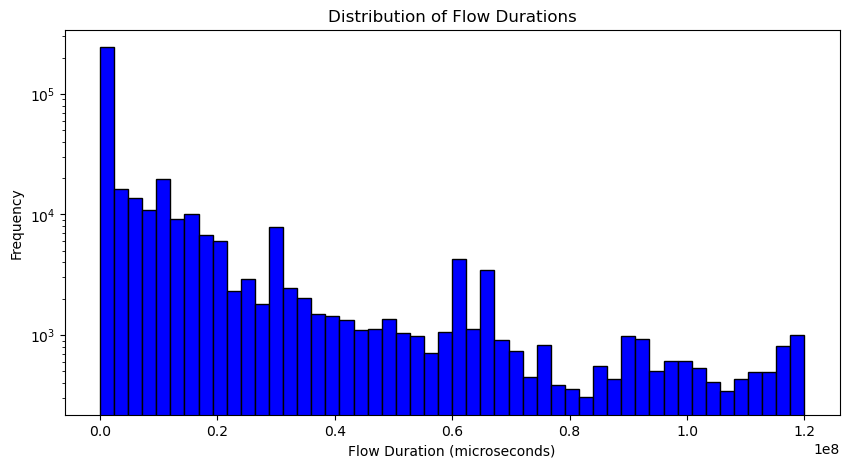

Number of flows with duration ≤ 1 µs: 42
30047          Benign
31935          Benign
31978          Benign
151163          Koler
189598      PornDroid
192547      PornDroid
193211      PornDroid
222618      PornDroid
302845     Simplocker
302944     Simplocker
302957     Simplocker
311610         SVpeng
332508         SVpeng
332513         SVpeng
332591         SVpeng
332648         SVpeng
332979         SVpeng
333511         SVpeng
334220         SVpeng
334387         SVpeng
335628         SVpeng
335629         SVpeng
335633         SVpeng
335636         SVpeng
335637         SVpeng
335640         SVpeng
335651         SVpeng
335793         SVpeng
336027         SVpeng
336860         SVpeng
339447         SVpeng
340170         SVpeng
341229         SVpeng
341239         SVpeng
343219         SVpeng
343586         SVpeng
343785         SVpeng
344510         SVpeng
345193         SVpeng
345223         SVpeng
345647         SVpeng
368308    WannaLocker
Name: Label, dtype: object
Number o

In [6]:
print(df[' Flow Duration'].describe())
# Plot histogram of flow duration
plt.figure(figsize=(10,5))
plt.hist(df[' Flow Duration'], bins=50, color='blue', edgecolor='black')
plt.xlabel("Flow Duration (microseconds)")
plt.ylabel("Frequency")
plt.title("Distribution of Flow Durations")
plt.yscale('log')  # Log scale for better visualization if data is skewed
plt.show()
# Check very short flows
short_flows = df[df[' Flow Duration'] <= 1]
print(f"Number of flows with duration ≤ 1 µs: {len(short_flows)}")
print(short_flows['Label'])
#All short flows belong to a ransomware attack so, I decided its nessecary and it kept
#Check for long flows(≥ 120 sec)
long_flows = df[df[' Flow Duration'] >= 120_000_000]
print(f"Number of long connections (≥120 sec): {len(long_flows)}")
# Print the label column to see if they are ransomware-related
print(long_flows['Label'].value_counts())


In [8]:
#Data normalization 
#Encoding cat col(expect Label - Label Encoding
from sklearn.preprocessing import LabelEncoder
categorical_cols = df.select_dtypes(include=['object']).columns
categorical_cols = categorical_cols[categorical_cols != 'Label'] 
label_encoders = {}  
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col]) 
    label_encoders[col] = le  
print(df.head())


   Flow ID   Source IP   Source Port   Destination IP   Destination Port  \
0   151293          14         51023             1323                443   
1   151293          14         51023             1323                443   
2   148222          14         34259             1289                443   
3   142965          14         55509             1242                443   
4   151265          14         44852             1323                443   

    Protocol   Flow Duration   Total Fwd Packets   Total Backward Packets  \
0          6          151054                   6                        8   
1          6             349                   2                        0   
2          6             119                   2                        0   
3          6           37055                   1                        1   
4          6          178727                   6                        7   

   Total Length of Fwd Packets  ...   Active Std   Active Max   Active Min  \
0 

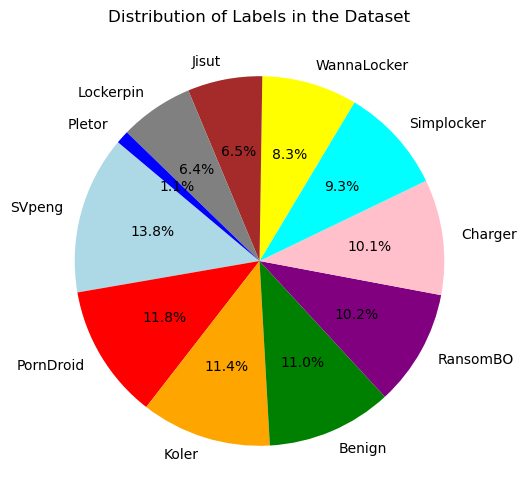

In [9]:
# Count occurrences of each label
label_counts = df["Label"].value_counts()

# Plot the pie chart
plt.figure(figsize=(8, 6))
plt.pie(label_counts, labels=label_counts.index, autopct="%1.1f%%", startangle=140, colors=['lightblue', 'red', 'orange', 'green', 'purple', 'pink', 'cyan', 'yellow', 'brown', 'gray', 'blue'])
plt.title("Distribution of Labels in the Dataset")

# Show the plot
plt.show()

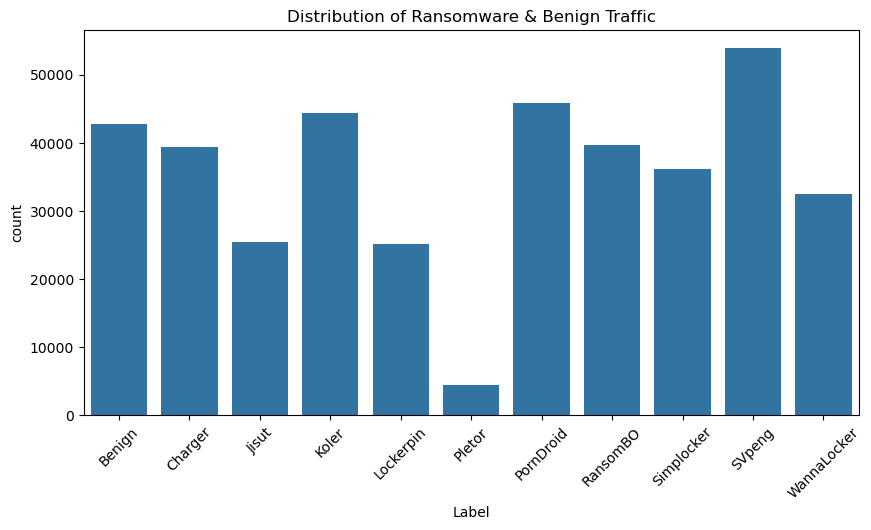

Label
SVpeng         53861
PornDroid      45850
Koler          44340
Benign         42722
RansomBO       39618
Charger        39322
Simplocker     36109
WannaLocker    32475
Jisut          25440
Lockerpin      25101
Pletor          4463
Name: count, dtype: int64


In [10]:
#Check for imbalance of dataset
# Count each class - Label
plt.figure(figsize=(10,5))
sns.countplot(x='Label', data=df)  
plt.xticks(rotation=45)
plt.title("Distribution of Ransomware & Benign Traffic")
plt.show()

# Print class distribution
print(df["Label"].value_counts())


In [11]:
import warnings
warnings.filterwarnings("ignore",category=UserWarning)
#from imblearn.over_sampling import SMOTE

#X = df.drop(columns=["Label"])
#y = df["Label"] # Target

#smote = SMOTE(sampling_strategy="auto", random_state=42)
#X_resampled, y_resampled = smote.fit_resample(X, y)
#print(df["Label"].value_counts())
#SMOTE - Didn't balance the dataset

In [12]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [13]:
#undersampling - works well for large dataset - remove samples from Majority class - Dis: may cause loss of data
#oversampling - works well if you don't want to lose data - duplicates samples from minority class - Dis: causes high computational cost
#Using UNdersample
import warnings
warnings.filterwarnings("ignore",category=UserWarning)
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler(random_state=42)
X = df.drop(columns=['Label'])  # Features
y = df['Label']  # Target column
X_resampled, y_resampled = rus.fit_resample(X, y)
df = pd.concat([X_resampled, y_resampled], axis=1)

print(df['Label'].value_counts())


Label
Benign         4463
Charger        4463
Jisut          4463
Koler          4463
Lockerpin      4463
Pletor         4463
PornDroid      4463
RansomBO       4463
SVpeng         4463
Simplocker     4463
WannaLocker    4463
Name: count, dtype: int64


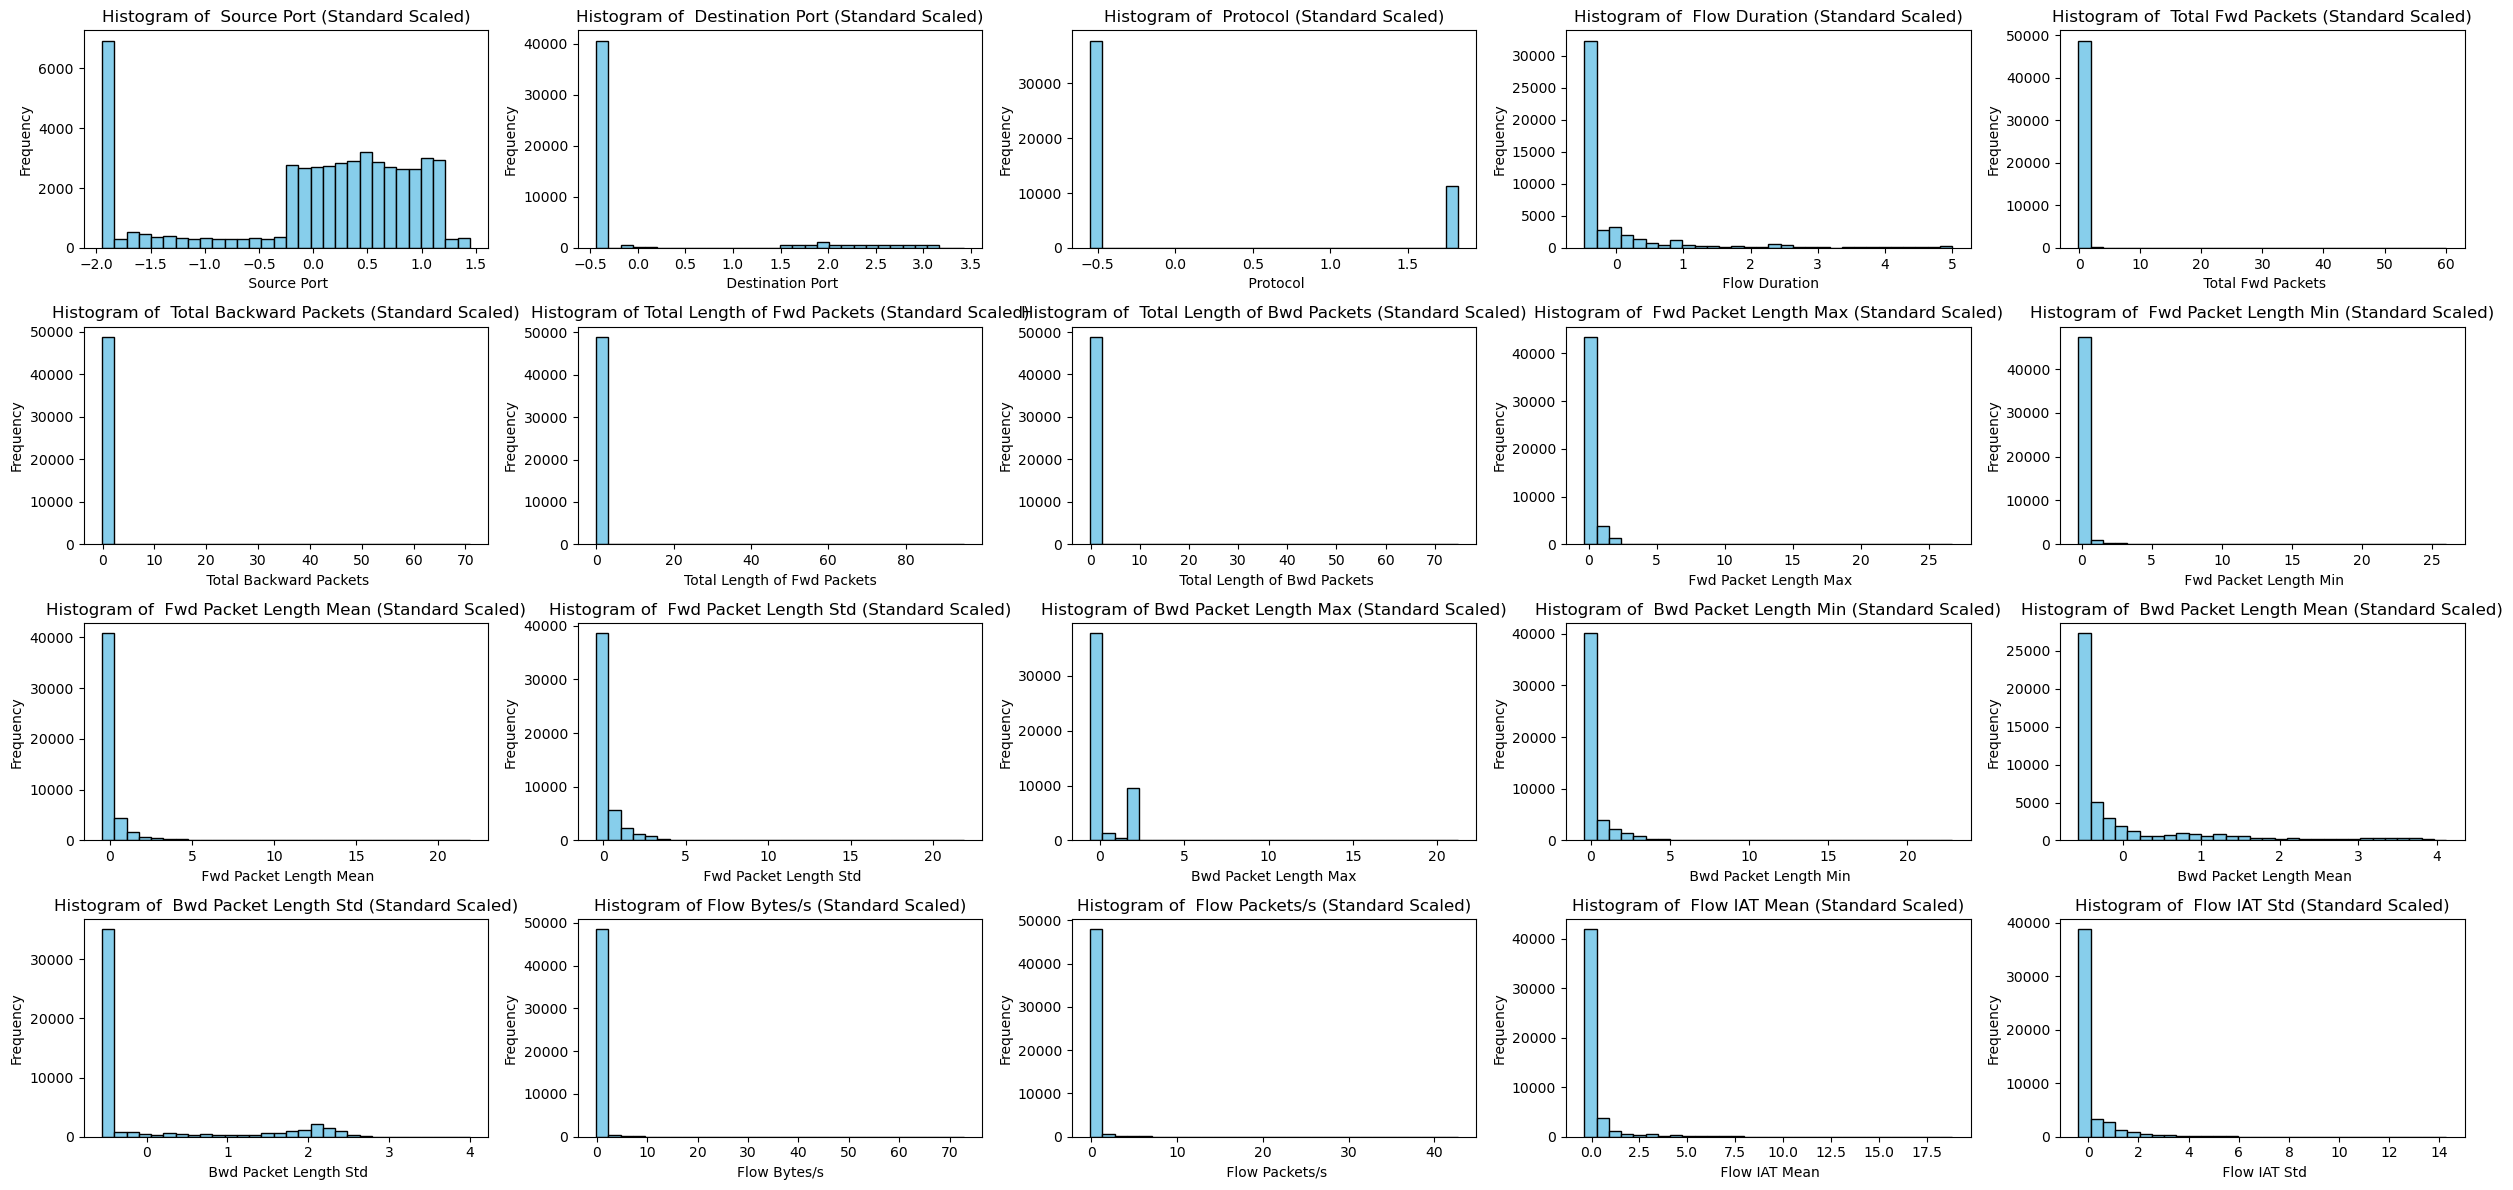

Standard Scaled image saved at: C:\Users\Mayuri\Desktop\standard_scaled_histograms.png


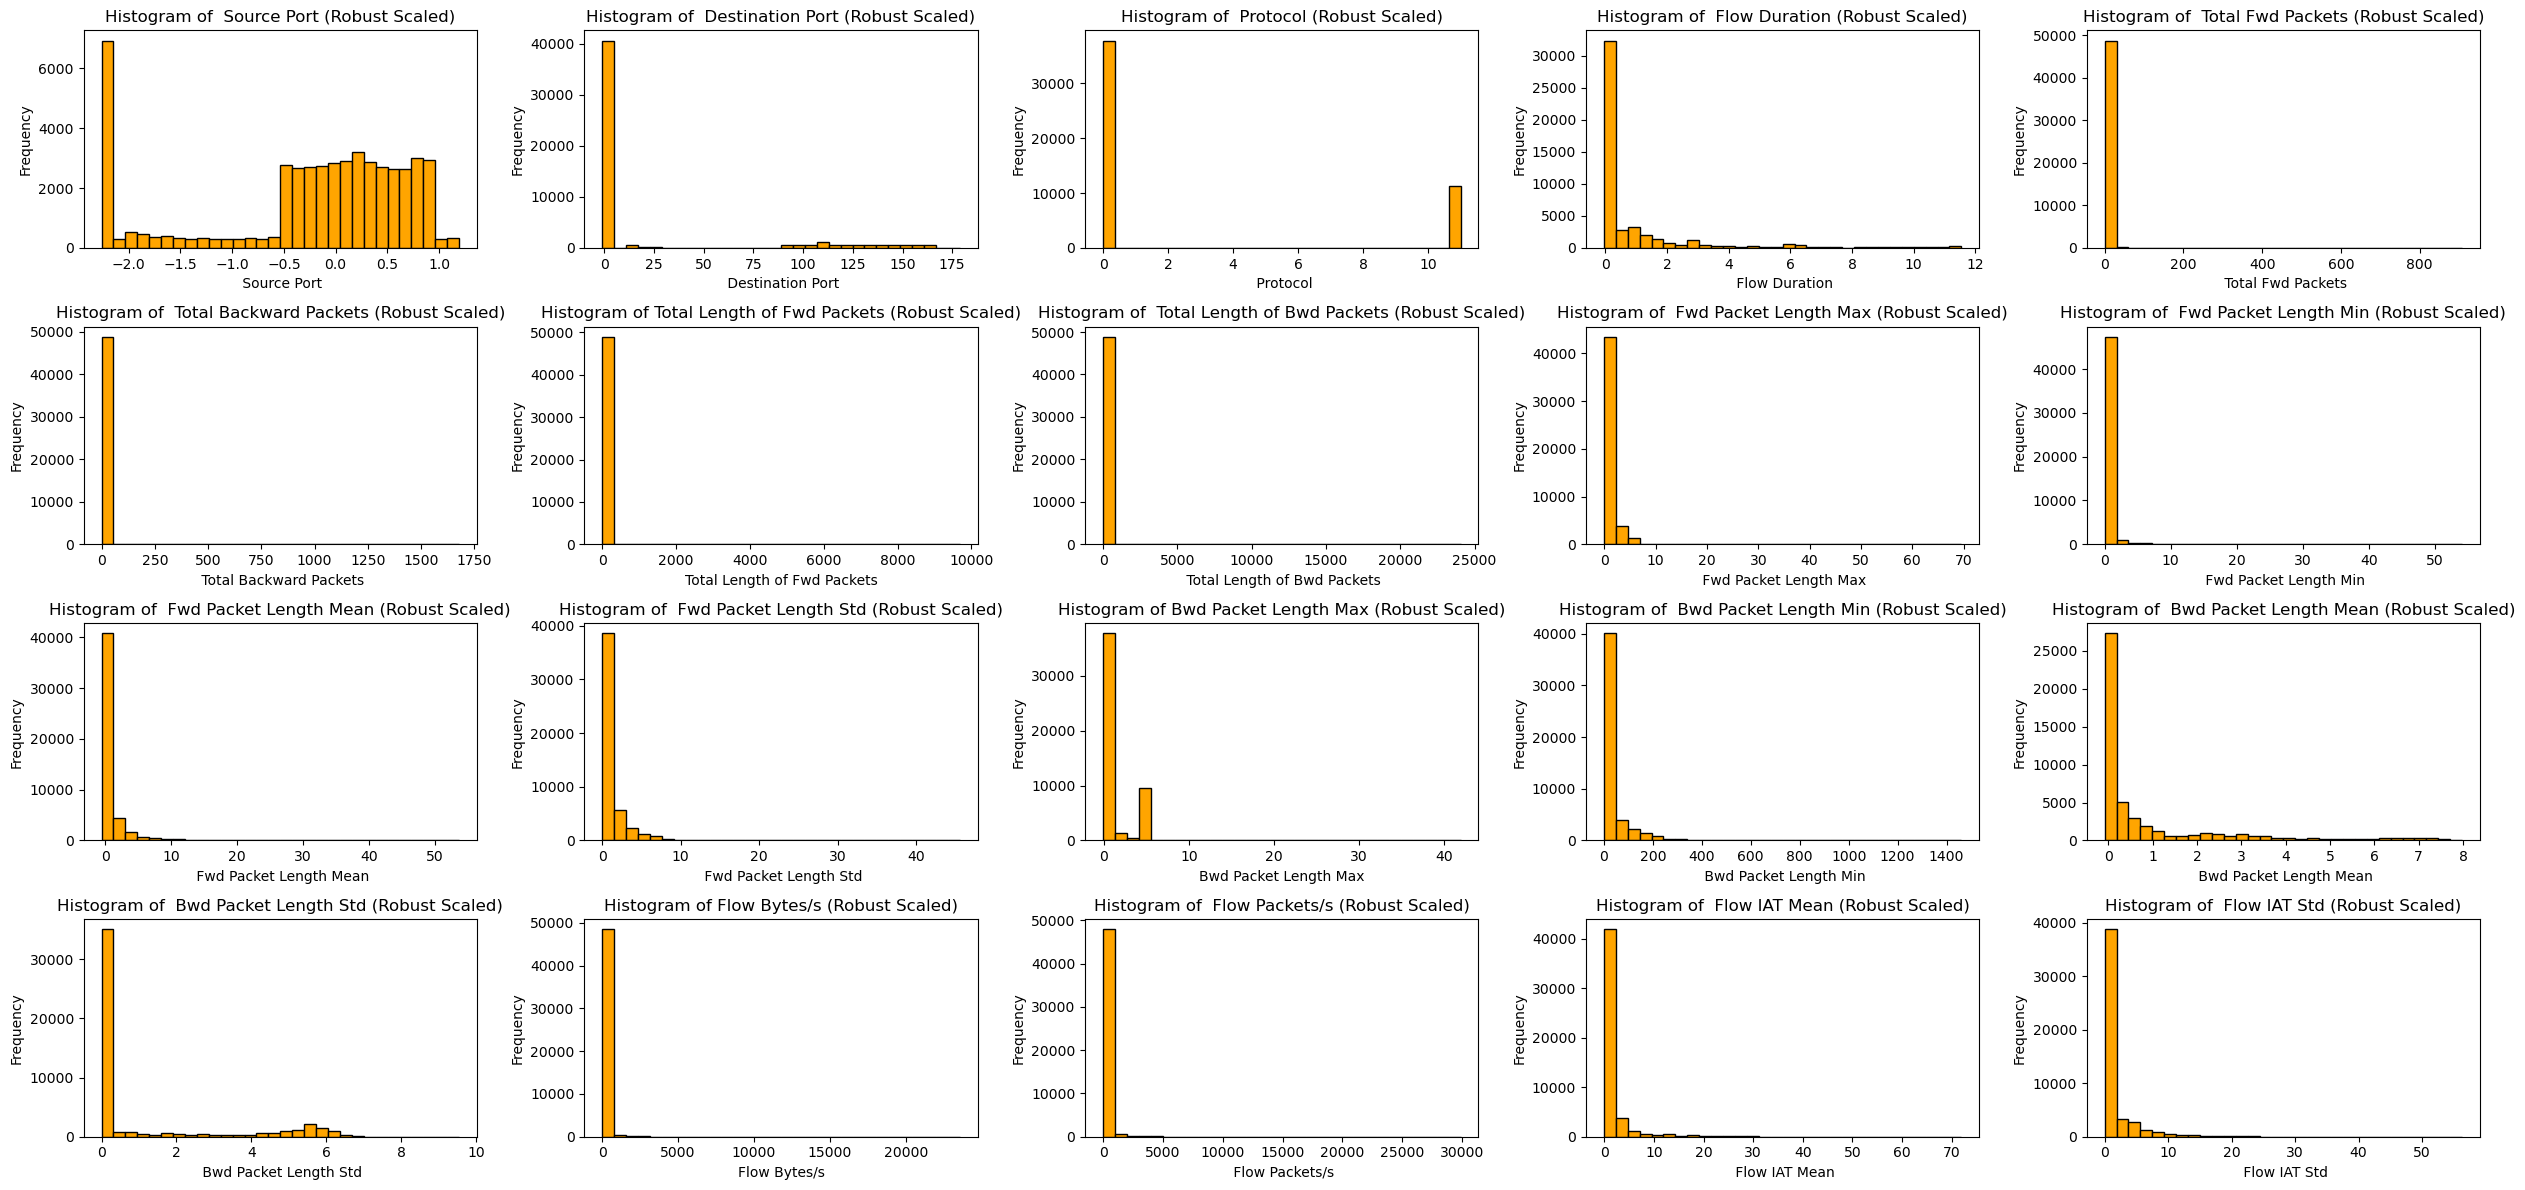

Robust Scaled image saved at: C:\Users\Mayuri\Desktop\robust_scaled_histograms.png


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, RobustScaler
import os

# Select numerical columns
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns[:20]  # First 20 features
num_features = len(numerical_cols)

# Apply StandardScaler
scaler_standard = StandardScaler()
df_standard_scaled = df.copy()
df_standard_scaled[numerical_cols] = scaler_standard.fit_transform(df[numerical_cols])

# Apply RobustScaler
scaler_robust = RobustScaler()
df_robust_scaled = df.copy()
df_robust_scaled[numerical_cols] = scaler_robust.fit_transform(df[numerical_cols])

# Define 8 columns and calculate required rows dynamically
cols = 5  # Fixed to 8 columns
rows = int(np.ceil(num_features / cols))  # Adjust rows accordingly

# Get desktop path
desktop_path = os.path.join(os.path.expanduser("~"), "Desktop")

# Function to plot and save histograms
def plot_and_save(data, title, filename, color):
    fig, axes = plt.subplots(rows, cols, figsize=(25, 3 * rows))  # Adjust figure size
    axes = axes.flatten()

    for i, col in enumerate(numerical_cols):
        axes[i].hist(data[col], bins=30, color=color, edgecolor='black')
        axes[i].set_title(f"Histogram of {col} ({title})")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Frequency")

    # Remove empty subplots
    for i in range(num_features, len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout()
    
    # Save the image to Desktop
    image_path = os.path.join(desktop_path, filename)
    plt.savefig(image_path, dpi=300)
    plt.show()
    
    print(f"{title} image saved at: {image_path}")

# Plot and save Standard Scaler histograms
plot_and_save(df_standard_scaled, "Standard Scaled", "standard_scaled_histograms.png", "skyblue")

# Plot and save Robust Scaler histograms
plot_and_save(df_robust_scaled, "Robust Scaled", "robust_scaled_histograms.png", "orange")


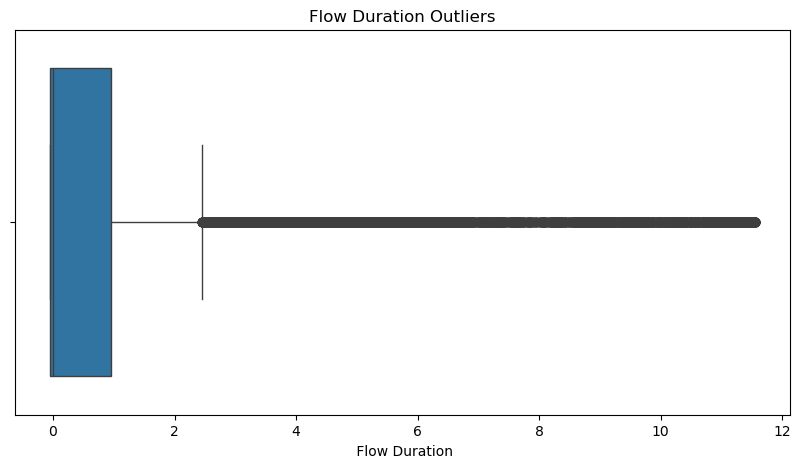

In [15]:
#Detect outliers in Flow duration 
plt.figure(figsize=(10,5))
sns.boxplot(x=df_robust_scaled[" Flow Duration"])  
plt.title("Flow Duration Outliers")
plt.show()
#Graph clearly shows extreme high values outliers

IndexError: index 84 is out of bounds for axis 0 with size 84

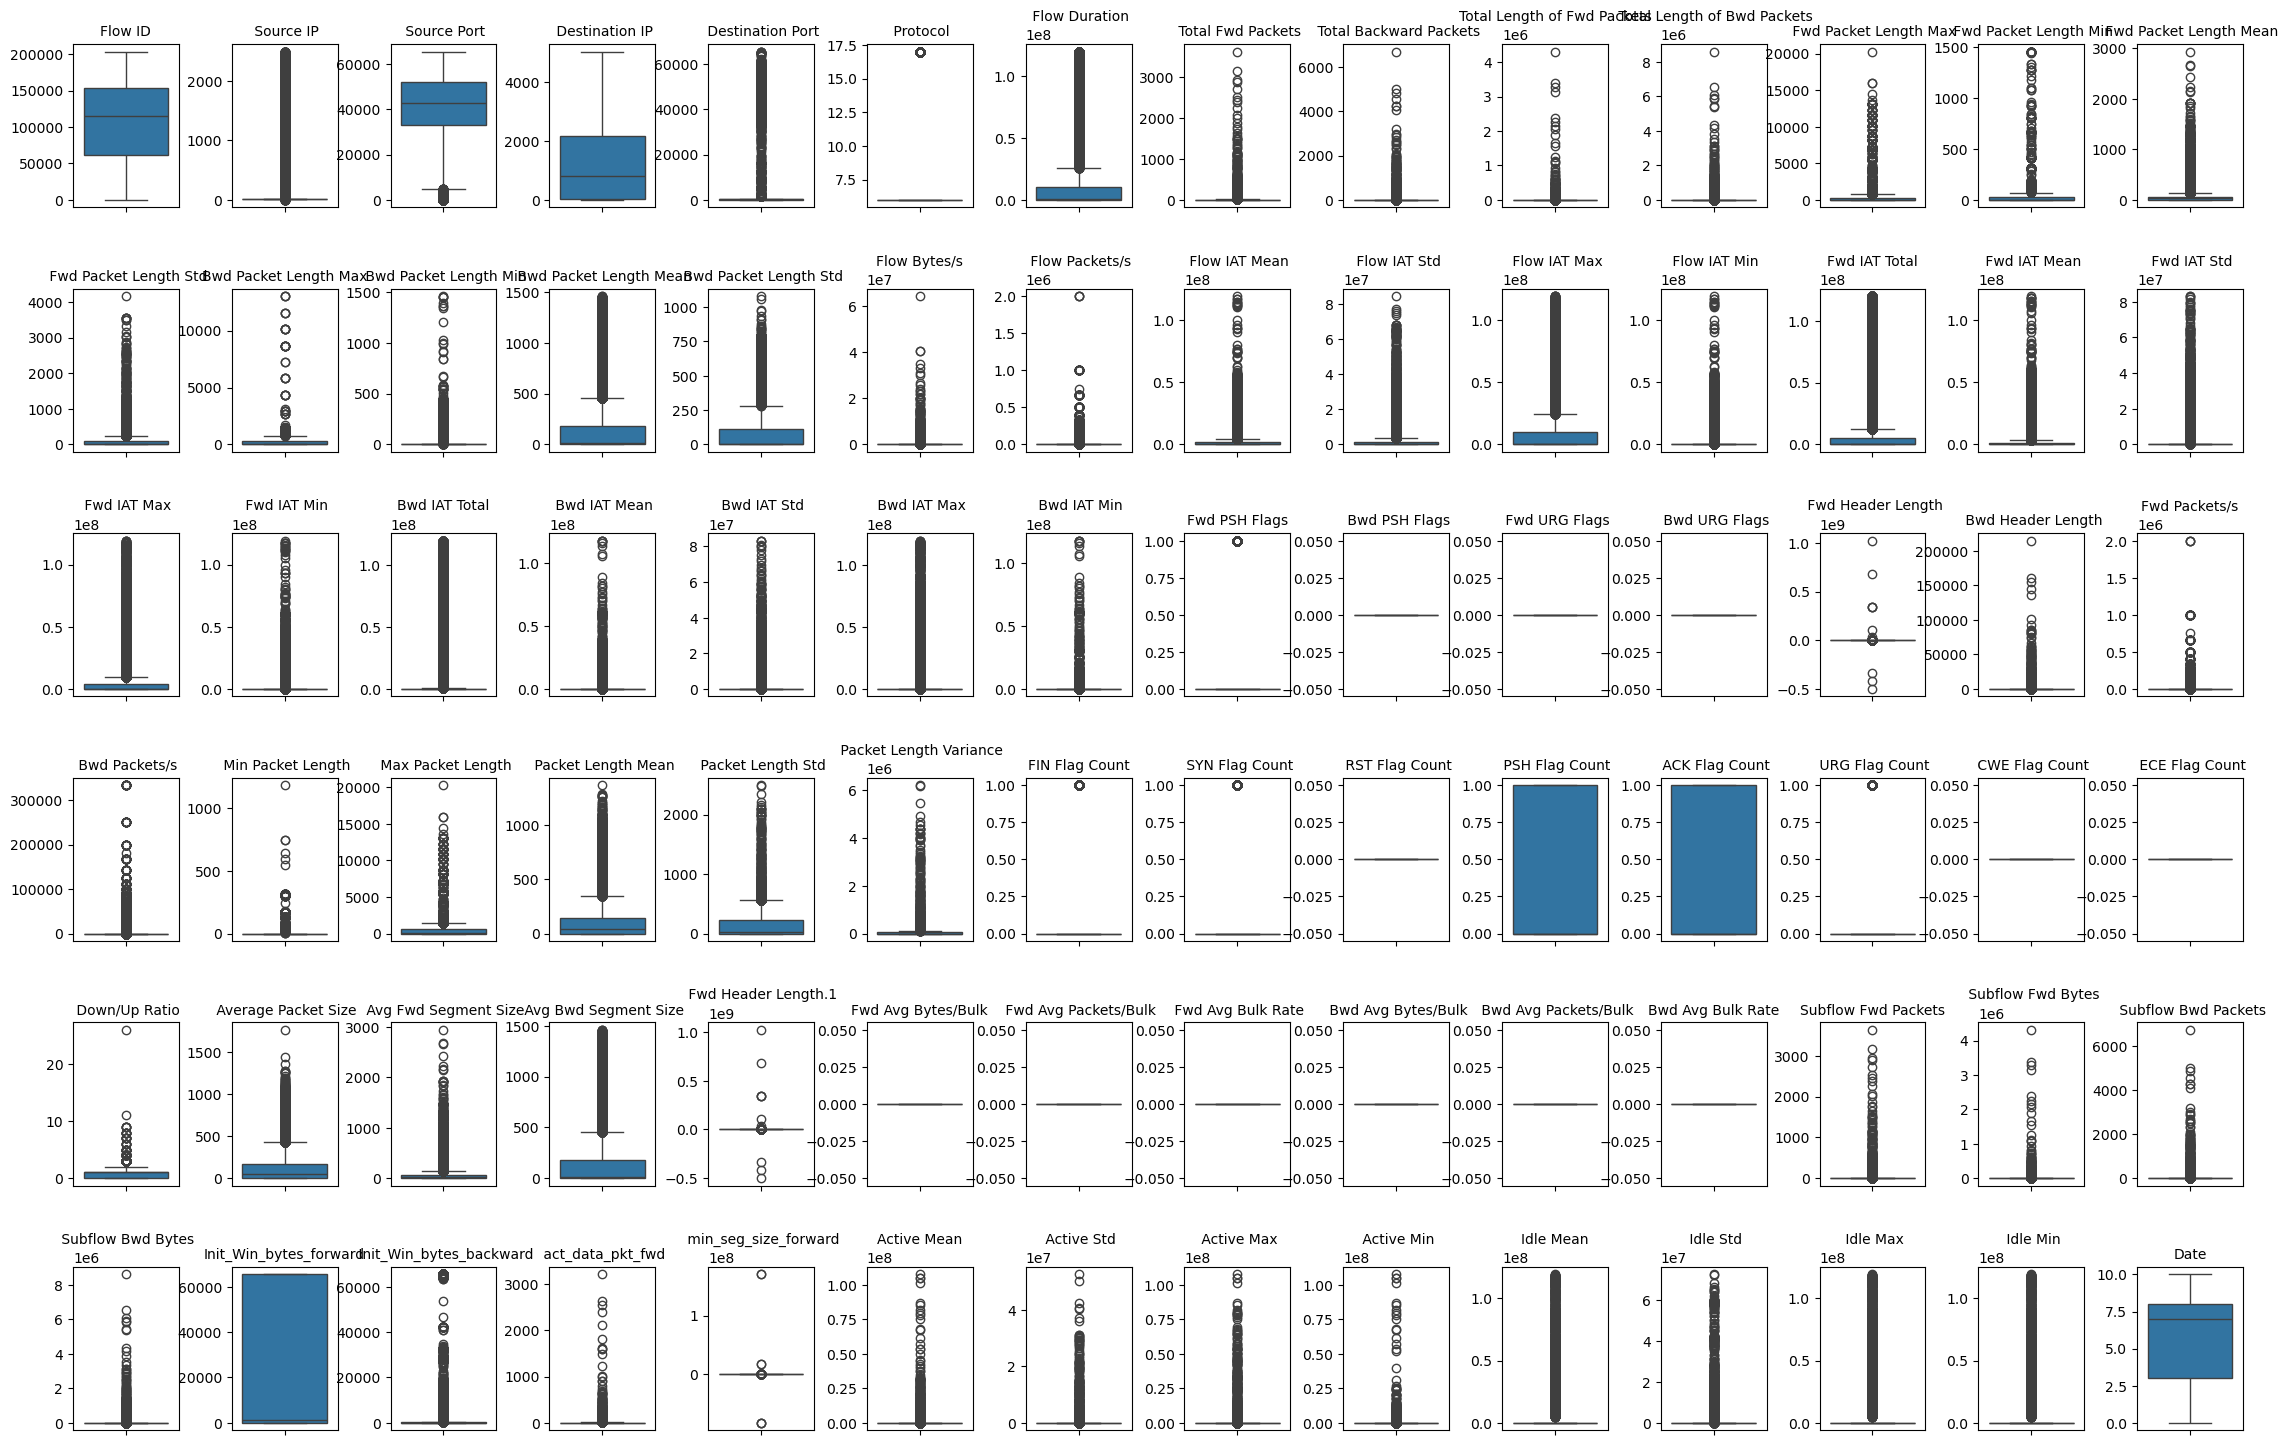

In [16]:
# Identify numerical columns
numerical_cols = df.select_dtypes(include=['number']).columns

# Set up the figure with subplots
fig, axes = plt.subplots(nrows=6, ncols=14, figsize=(28, 18))  # Adjust figure size for clarity
fig.subplots_adjust(hspace=0.5, wspace=0.5)  # Adjust spacing between subplots

# Flatten axes array for easy iteration
axes = axes.flatten()

# Create boxplots for each numerical column
for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

# Hide any unused subplots
for j in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[j])

# Show the plot
plt.show()

In [32]:
df[df_robust_scaled.columns] = df_robust_scaled
# Identify numerical columns in original df
numerical_cols = df_robust_scaled.columns

# Copy scaled numerical columns back to df
df[numerical_cols] = df_robust_scaled[numerical_cols]


In [34]:
#Radviz Diagram - multi dimenstionality data visulaization
#Why to use this? - see how network traffic clusters (Benign vs. Ransomware) and identify which feature separate ransomware traffic from normal traffic
#1. to select the top correlated features
# Ensure "Label" is numerical so it appears in the correlation matrix
df["Label"] = df["Label"].astype("category").cat.codes  

# Compute correlation matrix using only numerical columns
correlation_matrix = df.select_dtypes(include=["number"]).corr()

# Check if "Label" exists in the correlation matrix
if "Label" in correlation_matrix.columns:
    target_corr = correlation_matrix["Label"].abs().sort_values(ascending=False)
    
    # Select the top 5 highly correlated numerical features (excluding "Label" itself)
    top_features = target_corr.iloc[1:6].index  # Use iloc to avoid errors
    
    print("Top 5 highly correlated numerical features:", top_features)
else:
    print("Error: 'Label' not found in correlation matrix. Check if it was removed.")


#When selecting important features, we check their correlation with the target ("Label").
#+1: Strong positive relationship (Feature ↑, Target ↑)
#-1: Strong negative relationship (Feature ↑, Target ↓)
#0: No relationship
#Taking the absolute value ensures we pick both positively and negatively correlated features, as both help in classification.



Top 5 highly correlated numerical features: Index(['Date', 'Flow ID', 'Time', ' Fwd IAT Max', ' Flow IAT Mean'], dtype='object')


C:\Users\Mayuri\AppData\Local\Temp\ipykernel_19692\1187333349.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", len(unique_labels))  # Get distinct colors for labels


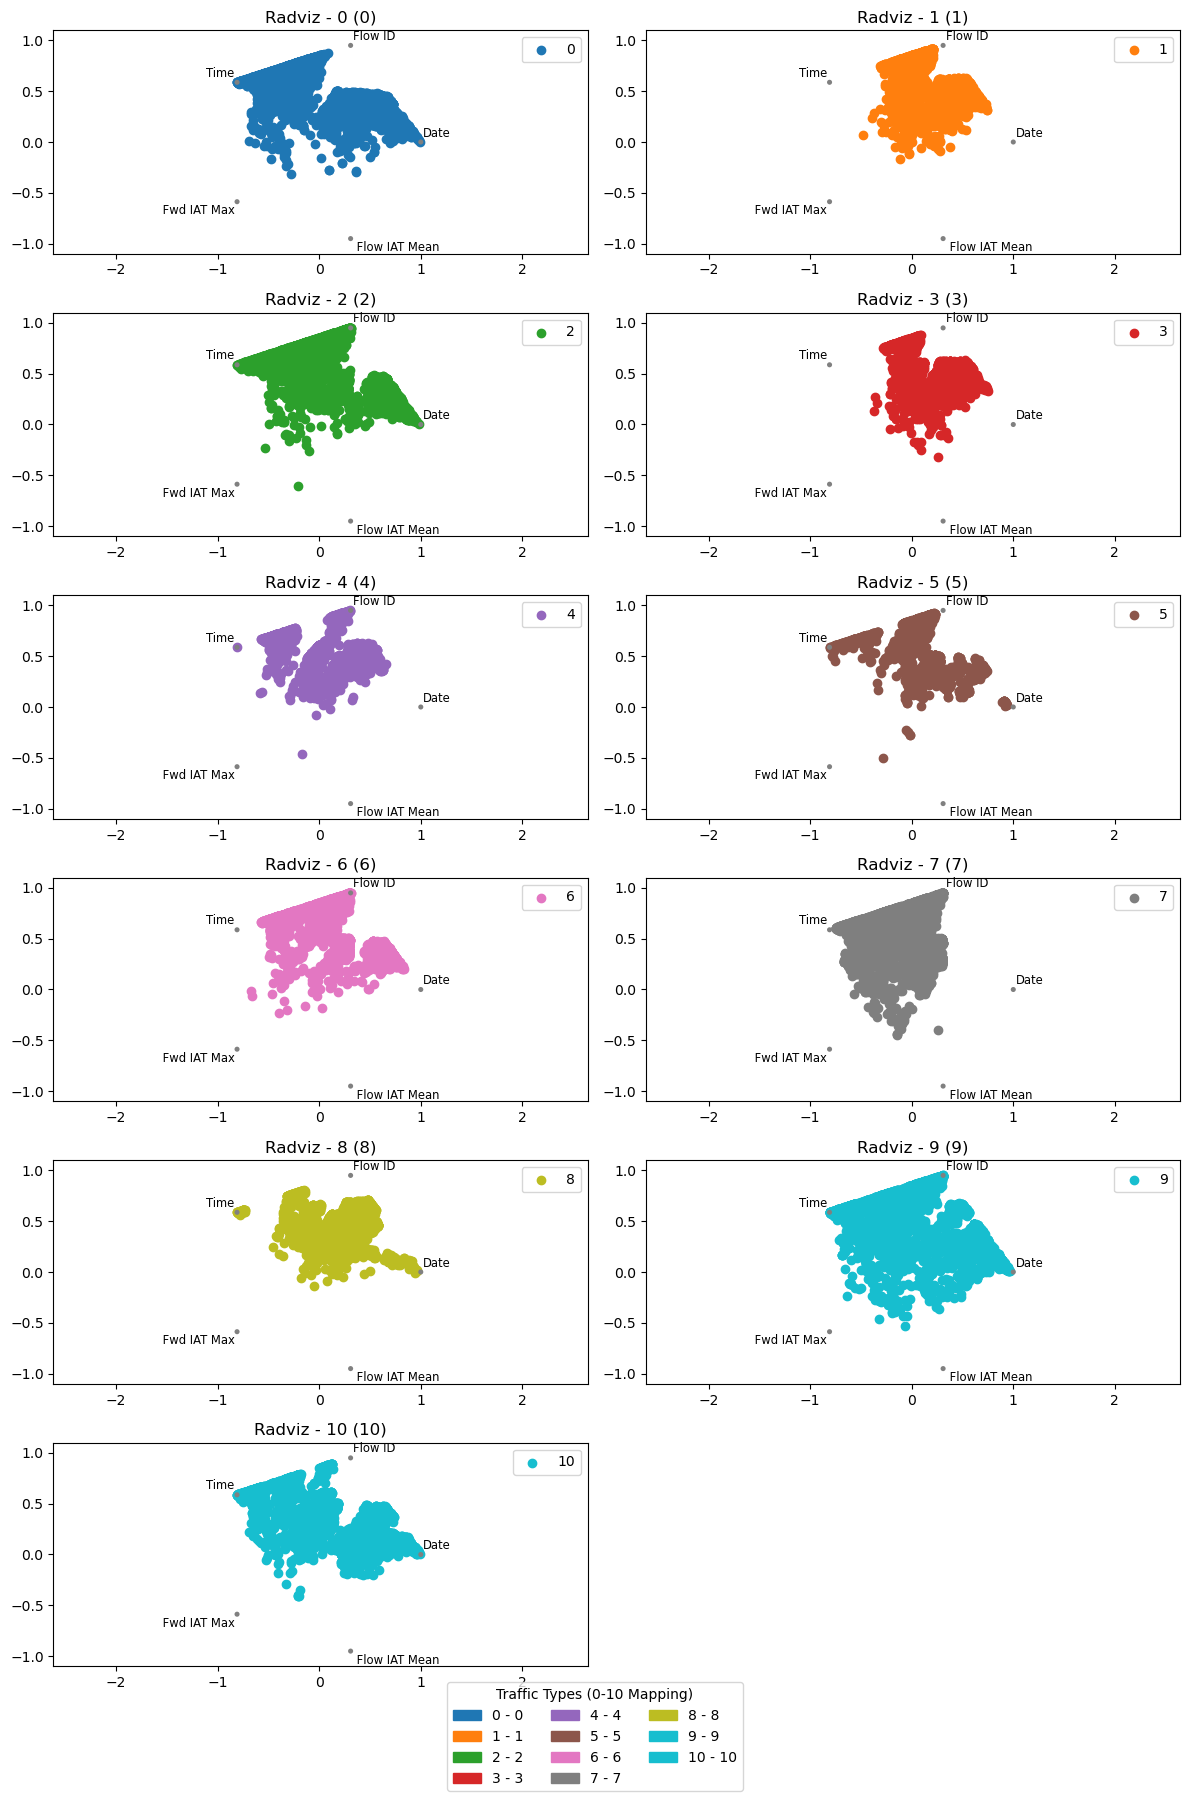

Radviz plot saved to: C:\Users\Mayuri\Desktop\radviz_plot.png


In [35]:
from pandas.plotting import radviz
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

# Ensure selected features exist in the dataset
radviz_df = df[list(top_features) + ["Label"]]

# Get unique network traffic types
unique_labels = sorted(radviz_df["Label"].unique())  # Sort for consistent mapping

# Map network traffic types to numbers from 0 to 10
label_mapping = {label: i for i, label in enumerate(unique_labels)}

# Define subplot layout (6 rows, 2 columns)
fig, axes = plt.subplots(nrows=6, ncols=2, figsize=(12, 18))  # Adjust size for readability
axes = axes.flatten()  # Flatten for easier iteration

# Generate Radviz plot for each traffic type
colors = plt.cm.get_cmap("tab10", len(unique_labels))  # Get distinct colors for labels

for i, label in enumerate(unique_labels):
    subset = radviz_df[radviz_df["Label"] == label]  # Filter one class at a time
    
    plt.sca(axes[i])  # Set current axis
    radviz(subset, class_column="Label", color=colors(i))  # Plot Radviz with color
    
    axes[i].set_title(f"Radviz - {label_mapping[label]} ({label})")  # Show number + label

# Create a legend with actual traffic types mapped to numbers (0-10)
legend_patches = [
    mpatches.Patch(color=colors(i), label=f"{label_mapping[label]} - {label}")
    for i, label in enumerate(unique_labels)
]
fig.legend(handles=legend_patches, loc="lower center", ncol=3, fontsize=10, title="Traffic Types (0-10 Mapping)")

# Hide any extra empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0.05, 1, 1])  # Adjust layout to fit the legend

# Save image to desktop
desktop_path = os.path.join(os.path.expanduser("~"), "Desktop", "radviz_plot.png")
plt.savefig(desktop_path, dpi=300, bbox_inches='tight')  # High-quality save

plt.show()

print(f"Radviz plot saved to: {desktop_path}")


In [36]:
# Split dataset in to train and test sets (80/20) - Large dataset
from sklearn.model_selection import train_test_split
X = df.drop(columns=['Label'])  
y = df['Label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape}, Testing set: {X_test.shape}")


Training set: (39274, 85), Testing set: (9819, 85)


In [37]:
#Classification metrics b4 feature selection
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("Accuracy before feature selection:", accuracy_score(y_test, y_pred))

Accuracy before feature selection: 0.9524391485894694


C:\Users\Mayuri\AppData\Local\Temp\ipykernel_19692\1917652177.py:12: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  mutual_info = mutual_info_classif(X_train, y_train.ravel())


Top Features based on Mutual Information:
Date                            1.494686
Flow ID                         1.252926
 Source IP                      0.863513
Time                            0.857775
 Destination IP                 0.468121
 Source Port                    0.211692
Init_Win_bytes_forward          0.154025
 Flow Duration                  0.146162
 Flow IAT Max                   0.144064
 Fwd Packet Length Max          0.141657
Total Length of Fwd Packets     0.132636
 Flow IAT Min                   0.132479
 Subflow Fwd Bytes              0.131439
 Average Packet Size            0.129197
Fwd Packets/s                   0.124744
 Flow IAT Mean                  0.123892
 Packet Length Variance         0.123714
 Init_Win_bytes_backward        0.121409
 Packet Length Mean             0.120922
 Flow Packets/s                 0.119330
 Packet Length Std              0.112970
 Fwd IAT Min                    0.111302
 Max Packet Length              0.108032
 Avg Fwd Segmen

C:\Users\Mayuri\AppData\Local\Temp\ipykernel_19692\1917652177.py:20: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  X_train_selected = selector.fit_transform(X_train, y_train.ravel())


Selected features: ['Flow ID', ' Source IP', ' Source Port', ' Destination IP', ' Destination Port', ' Flow Duration', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Max', ' Bwd IAT Min', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance', ' Average Packet Size', ' Avg Fwd Segment Size', ' Avg Bwd Segment Size', ' Fwd Header Length.1', ' Subflow Fwd Bytes', ' Subflow Bwd Bytes', 'Init_Win_bytes_forward', ' Init_Win_

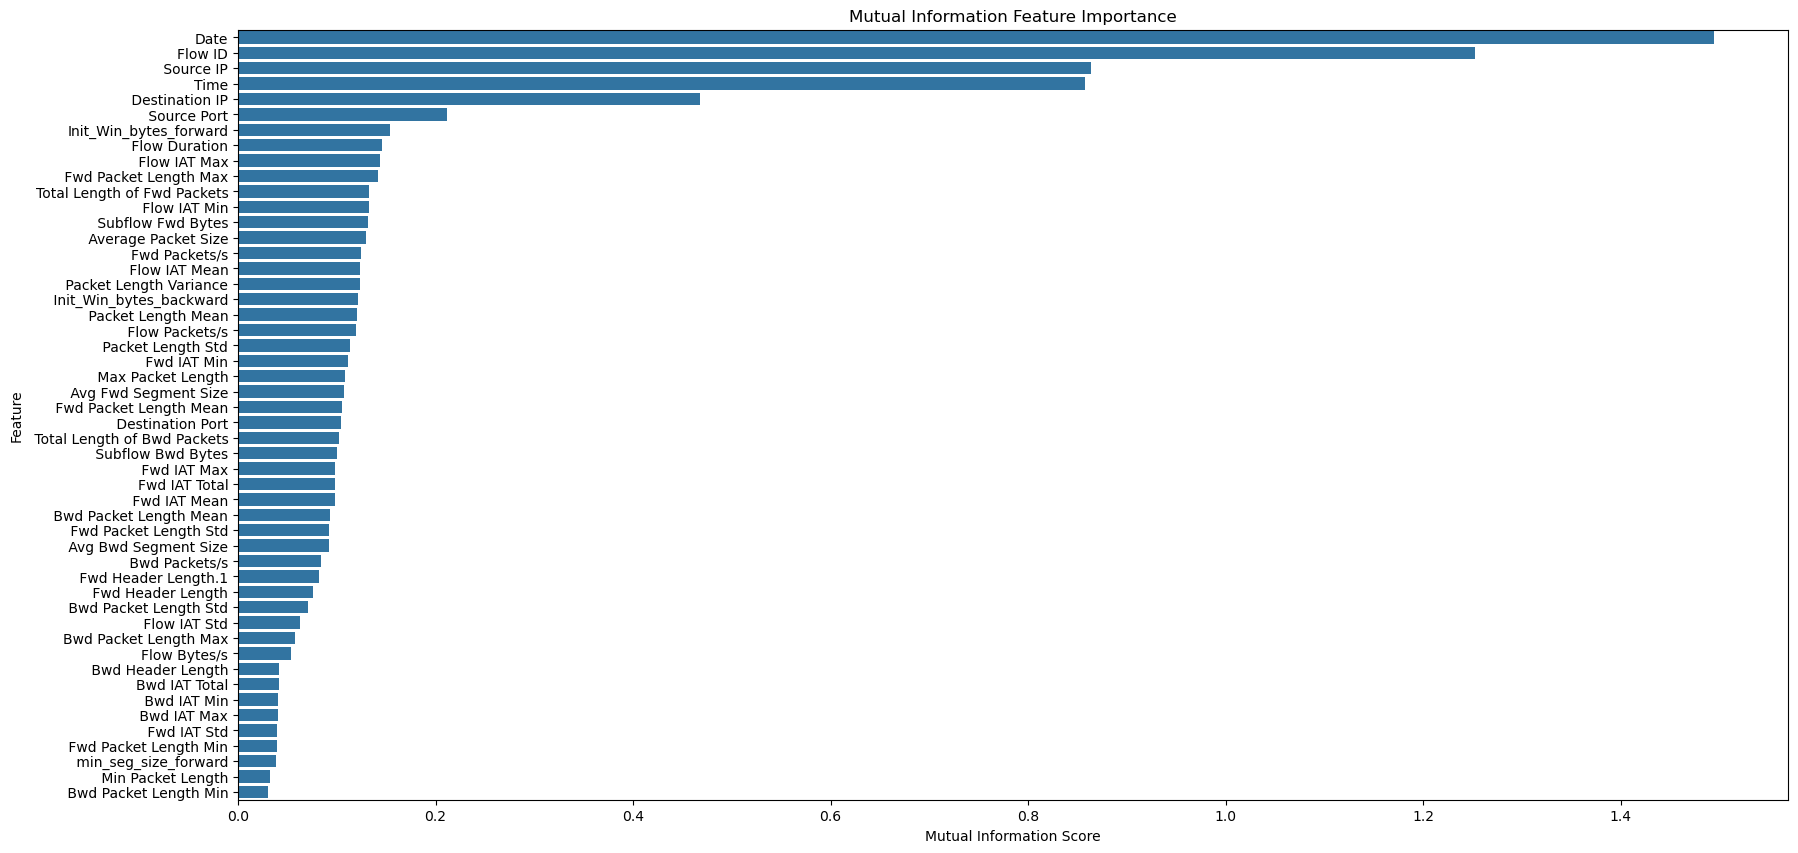

In [38]:
# Hybrid Feature Selection
# Filter Method - Mutual Information
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif, SelectKBest
from sklearn.ensemble import RandomForestClassifier

# Ensure X_train, X_test, and y_train are defined before using them

# Mutual Information (Filter Method)
mutual_info = mutual_info_classif(X_train, y_train.ravel())
mutual_info_series = pd.Series(mutual_info, index=X_train.columns).sort_values(ascending=False)

print("Top Features based on Mutual Information:")
print(mutual_info_series.head(50))  # Display top 20 features

# Select K-best (K=50) using Mutual Information
selector = SelectKBest(mutual_info_classif, k=50)
X_train_selected = selector.fit_transform(X_train, y_train.ravel())
X_test_selected = selector.transform(X_test)

# Get selected feature names
selected_features = X_train.columns[selector.get_support()].tolist()
print("Selected features:", selected_features)

# Visualization of Mutual Information Scores
plt.figure(figsize=(20, 10))
sns.barplot(x=mutual_info_series.head(50).values, y=mutual_info_series.head(50).index, orient='h')  # Show top 20 features
plt.xlabel("Mutual Information Score")
plt.ylabel("Feature")
plt.title("Mutual Information Feature Importance")
plt.show()


C:\Users\Mayuri\AppData\Local\Temp\ipykernel_19692\1816992113.py:10: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  X_train_rfe = rfe.fit_transform(X_train_selected, y_train.ravel())



Final Selected Features (After RFE): ['Flow ID', ' Source IP', ' Source Port', ' Destination IP', ' Destination Port', ' Flow Duration', ' Fwd Packet Length Max', ' Fwd Packet Length Mean', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Max', ' Fwd IAT Min', ' Fwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Packet Length Mean', ' Average Packet Size', ' Avg Fwd Segment Size', ' Fwd Header Length.1', ' Subflow Fwd Bytes', 'Init_Win_bytes_forward', ' Init_Win_bytes_backward', 'Date', 'Time']


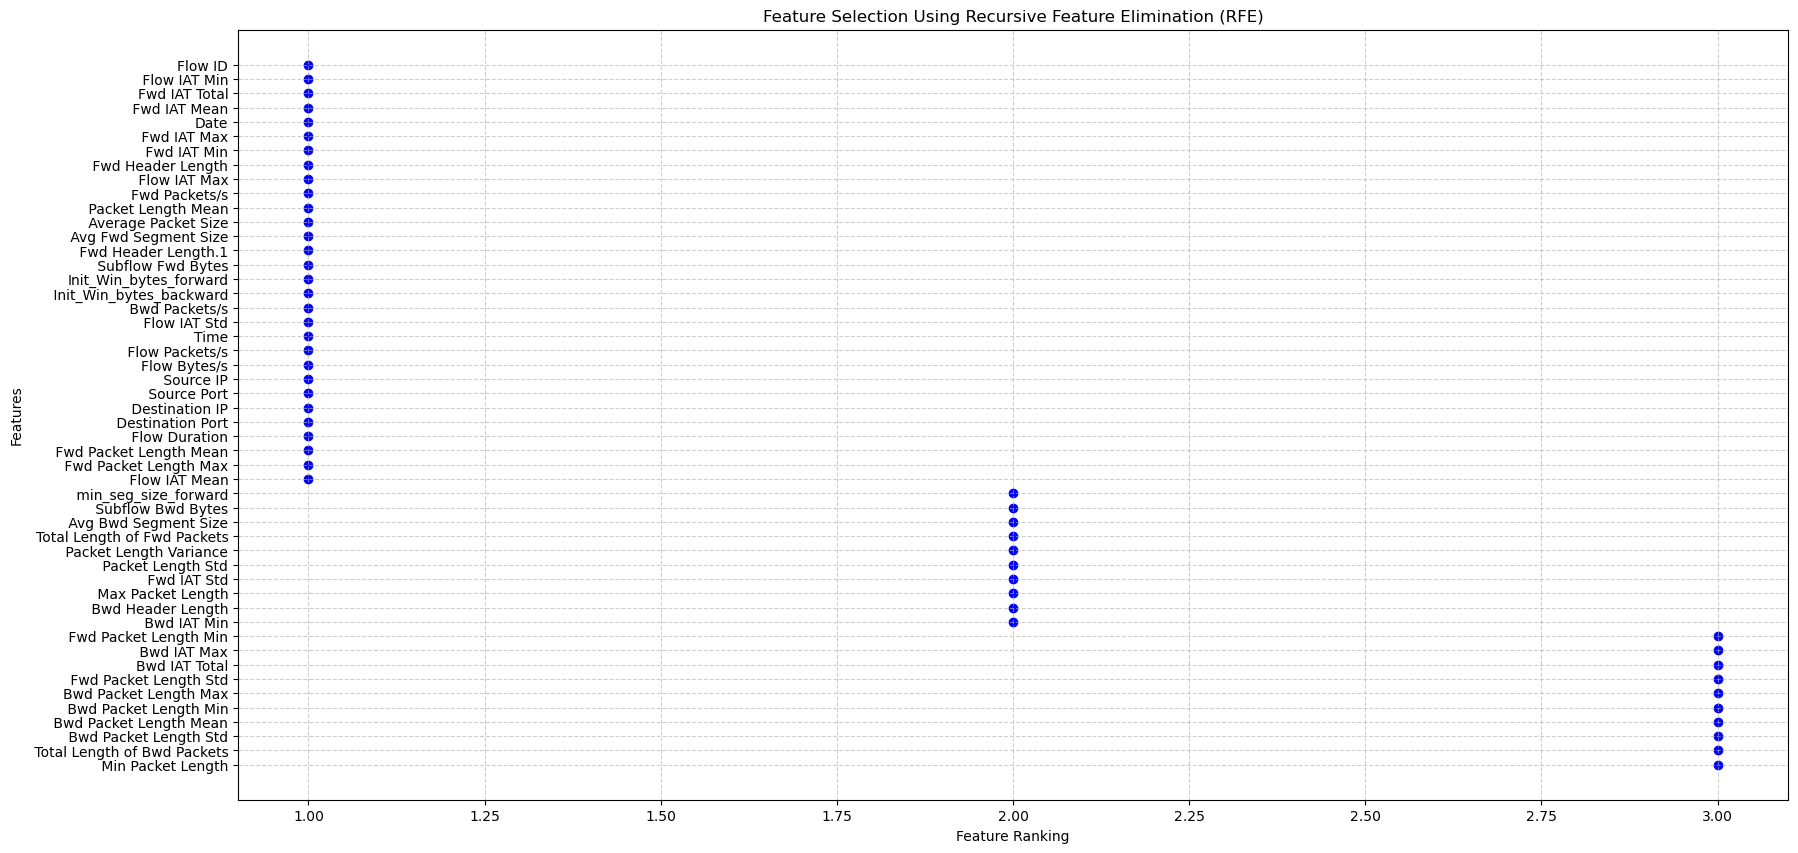

Shape of final selected features (Train): (39274, 30)
Shape of final selected features (Test): (9819, 30)


In [40]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE

# Wrapper method - Recursive Feature Elimination (RFE) 
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rfe = RFE(estimator=rf_model, n_features_to_select=30, step=10)  

X_train_rfe = rfe.fit_transform(X_train_selected, y_train.ravel())
X_test_rfe = rfe.transform(X_test_selected)

# Get final selected features after RFE
final_selected_features = [feature for feature, support in zip(selected_features, rfe.support_) if support]
print("\nFinal Selected Features (After RFE):", final_selected_features)

# Get feature rankings
feature_ranking = rfe.ranking_
selected_features = np.array(selected_features)  # Convert to NumPy array for indexing

# Sort features by ranking
sorted_indices = np.argsort(feature_ranking)
sorted_features = selected_features[sorted_indices]
sorted_ranking = feature_ranking[sorted_indices]

# Plot feature rankings using scatter plot
plt.figure(figsize=(20, 10))
plt.scatter(sorted_ranking, sorted_features, color='blue', marker='o')
plt.xlabel("Feature Ranking")
plt.ylabel("Features")
plt.title("Feature Selection Using Recursive Feature Elimination (RFE)")
plt.gca().invert_yaxis()  # Invert y-axis to show best features on top
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Print final shape
print("Shape of final selected features (Train):", X_train_rfe.shape)
print("Shape of final selected features (Test):", X_test_rfe.shape)


C:\Users\Mayuri\AppData\Local\Temp\ipykernel_19692\1485528732.py:8: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  rf_model.fit(X_train, y_train.ravel())
C:\Users\Mayuri\AppData\Local\Temp\ipykernel_19692\1485528732.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances[:15], y=feature_importances.index[:15], palette="viridis")


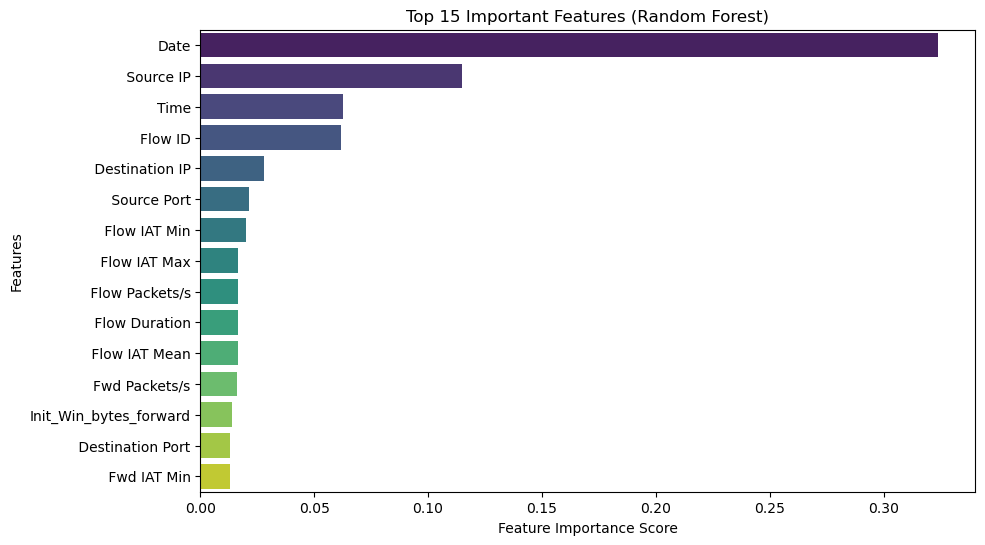


 Final Selected Features (Embedded Method - Random Forest): ['Flow ID', ' Source IP', ' Source Port', ' Destination IP', ' Destination Port', ' Flow Duration', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Max', ' Flow IAT Min', ' Fwd IAT Min', 'Fwd Packets/s', 'Init_Win_bytes_forward', 'Date', 'Time']
 Shape of final selected features (Train): (39274, 15)
Shape of final selected features (Test): (9819, 15)


In [41]:
# Embedded Method - Random Forest Feature Selection
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

# Train Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train.ravel())

# Feature Importance
feature_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
feature_importances = feature_importances.sort_values(ascending=False)

# Select Top 50 Features based on importance
selector = SelectFromModel(rf_model, threshold=-np.inf, max_features=15, prefit=True)
X_train_embedded = selector.transform(X_train)
X_test_embedded = selector.transform(X_test)

# Get selected feature names
selected_features_embedded = X_train.columns[selector.get_support()].tolist()
# Visualization
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances[:15], y=feature_importances.index[:15], palette="viridis")
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.title("Top 15 Important Features (Random Forest)")
plt.show()

print("\n Final Selected Features (Embedded Method - Random Forest):", selected_features_embedded)
print(" Shape of final selected features (Train):", X_train_embedded.shape)
print("Shape of final selected features (Test):", X_test_embedded.shape)


In [42]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
# Train a classifier 
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_embedded, y_train.ravel())

# Predictions
y_pred = clf.predict(X_test_embedded)

# Classification Metrics
accuracy = accuracy_score(y_test, y_pred)


# Print Results
print(f" Accuracy after feature selection : {accuracy:}")



C:\Users\Mayuri\AppData\Local\Temp\ipykernel_19692\1821977587.py:5: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  clf.fit(X_train_embedded, y_train.ravel())


 Accuracy after feature selection : 0.9933801812811895


In [43]:
#Precision basically tell the positive values in it
#Recall tells the no.of of positive values that u are actually able to find
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score

# Train a classifier 
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_embedded, y_train)
y_pred = clf.predict(X_test_embedded)
precision_per_class = precision_score(y_test, y_pred, average=None)
recall_per_class = recall_score(y_test, y_pred, average=None)

# Print Precision & Recall for Each Class
for i, class_label in enumerate(y_test.unique()):
    print(f"Class: {class_label} | Precision: {precision_per_class[i]:} | Recall: {recall_per_class[i]:}")
#All are classfied around the range of 0.98 - 1.0 which means all the features selected are good.


Class: 2 | Precision: 1.0 | Recall: 1.0
Class: 8 | Precision: 0.9943946188340808 | Recall: 0.9932810750279956
Class: 3 | Precision: 0.9845132743362832 | Recall: 0.9966405375139977
Class: 9 | Precision: 0.9965792474344356 | Recall: 0.9787234042553191
Class: 6 | Precision: 0.9921787709497206 | Recall: 0.9944008958566629
Class: 1 | Precision: 0.9821627647714605 | Recall: 0.9876681614349776
Class: 7 | Precision: 0.9944071588366891 | Recall: 0.9955207166853304
Class: 0 | Precision: 0.9855555555555555 | Recall: 0.9932810750279956
Class: 4 | Precision: 0.9988738738738738 | Recall: 0.9932810750279956
Class: 10 | Precision: 1.0 | Recall: 0.9943946188340808
Class: 5 | Precision: 0.9988801791713325 | Recall: 1.0


In [44]:
#Check for overfitting
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_selected, y_train)
y_train_pred = clf.predict(X_train_selected)
y_test_pred = clf.predict(X_test_selected)

# Compute F1 Score separately for Train & Test
f1_train = f1_score(y_train, y_train_pred, average="macro")
f1_test = f1_score(y_test, y_test_pred, average="macro")

# Print F1 Scores
print(f"\n F1 Score on Training Set before Turning: {f1_train:.4f}")
print(f"F1 Score on Test Set before turning: {f1_test:.4f}")
#It is clear that it is overfitting - Since f1 score of train set is more than testing set. The difference b/w f1 score is more there is overfitting



 F1 Score on Training Set before Turning: 1.0000
F1 Score on Test Set before turning: 0.9802


In [45]:
#Fine tuning and Hyperprameter needs to be done to reduce overfitting and improve accuracy
#Borad hyperprameter - Random Search+Stratifed 
# Use only the selected features from the embedded method
X_train_selected = X_train[selected_features_embedded]
X_test_selected = X_test[selected_features_embedded]
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier

param_dist = {
    "n_estimators": [50, 100, 150], 
    "max_depth": [5, 10, 15],  
    "min_samples_split": [10, 20], 
    "min_samples_leaf": [5, 10],  
    "bootstrap": [True]  
}

# Use Stratified K-Fold for cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize Random Forest model
rf = RandomForestClassifier(random_state=42)

# Apply Randomized Search
random_search = RandomizedSearchCV(
    rf, param_distributions=param_dist, n_iter=10, cv=cv, scoring="accuracy", 
    n_jobs=-1, random_state=42
)

# Fit model on selected features
random_search.fit(X_train_selected, y_train)

# Get best parameters
best_random_params = random_search.best_params_
print("\n Best Parameters from Random Search:", best_random_params)
print(f" Best Accuracy from Random Search: {random_search.best_score_:}")



 Best Parameters from Random Search: {'n_estimators': 150, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_depth': 15, 'bootstrap': True}
 Best Accuracy from Random Search: 0.9846462874253341


In [46]:
#Fine Turning done using grid search with the parameters from Random Search CV - Prevent overfitting
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier

# Adjust Grid Search parameters to fine-tune from Random Search results
param_grid = {
    "n_estimators": [150, 175, 200],  
    "max_depth": [12, 15, 18],  
    "min_samples_split": [10, 15],  
    "min_samples_leaf": [5, 8],  
    "bootstrap": [True] 
}

# Use Stratified K-Fold for balanced evaluation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    rf, param_grid=param_grid, cv=cv, scoring="accuracy", n_jobs=-1)

grid_search.fit(X_train_selected, y_train)

# Get best parameters
best_grid_params = grid_search.best_params_
print("\nBest Parameters from Grid Search:", best_grid_params)
print(f"Best Accuracy from Grid Search: {grid_search.best_score_:.4f}")



Best Parameters from Grid Search: {'bootstrap': True, 'max_depth': 18, 'min_samples_leaf': 5, 'min_samples_split': 10, 'n_estimators': 200}
Best Accuracy from Grid Search: 0.9884


In [47]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

# Train the final model using the best Grid Search parameters
best_rf = RandomForestClassifier(**best_grid_params, random_state=42)
best_rf.fit(X_train_selected, y_train)

# Predictions
y_train_pred = best_rf.predict(X_train_selected)
y_test_pred = best_rf.predict(X_test_selected)


# Compute F1 Score
train_f1 = f1_score(y_train, y_train_pred, average="macro")
test_f1 = f1_score(y_test, y_test_pred, average="macro")


print(f"\n Train F1 Score after Fine turning: {train_f1:}")
print(f" Test F1 Score after Fine turning: {test_f1:}")
#Difference between Train and test f1 score is very minimal now. Overfiiting managed now.


 Train F1 Score after Fine turning: 0.9972499733093213
 Test F1 Score after Fine turning: 0.9900165588469954


In [62]:
#DT
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Train Decision Tree Classifier with adjusted parameters
dt_model = DecisionTreeClassifier(
    max_depth=7,  # Reduce depth further to prevent overfitting
    min_samples_split=14,  # More samples required to split
    min_samples_leaf=8,  # More leaf samples to generalize
    criterion="entropy",  # Use entropy instead of gini
    random_state=42
)

# Fit the model
dt_model.fit(X_train_selected, y_train)

# Predictions on Test Set
y_test_pred = dt_model.predict(X_test_selected)

# Compute Accuracy
dt_accuracy = accuracy_score(y_test, y_test_pred)

# Print Accuracy
print(f"Decision Tree Model Accuracy: {dt_accuracy:.4f}")

Decision Tree Model Accuracy: 0.9507


In [76]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Feature Scaling (SVM is sensitive to scale)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled = scaler.transform(X_test_selected)

# Initialize SVM with better hyperparameters
svm_model = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)  # Higher C for better decision boundary

# Train the model
svm_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = svm_model.predict(X_test_scaled)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")


Test Accuracy: 0.8363


In [77]:
#XGBoost(Extreme gradient boosting) - good of high performance boosting and good for complex relationship
#note: XGBoost can handle missing values on its own
!pip install xgboost


In [65]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, f1_score, recall_score
from sklearn.model_selection import cross_val_score
import numpy as np

# Initialize XGBoost model
xgb_model = XGBClassifier(
    n_estimators=80,  
    max_depth=3,  
    learning_rate=0.08,  
    reg_lambda=8,  
    random_state=42,
    use_label_encoder=False,  # Fixes sklearn compatibility issue
    eval_metric="logloss"  # Explicitly set evaluation metric
)

# Fit model
xgb_model.fit(X_train_selected, y_train)

# Predictions
y_test_pred = xgb_model.predict(X_test_selected)

# Compute Metrics
xgb_accuracy = accuracy_score(y_test, y_test_pred)

# Print Results
print(f"XGBoost Model Accuracy: {xgb_accuracy:.4f}")



XGBoost Model Accuracy: 0.9882


In [66]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train_selected, y_train)

y_test_pred = rf_model.predict(X_test_selected)

# Compute Accuracy
rf_accuracy = accuracy_score(y_test, y_test_pred)

# Print Accuracy
print(f"Random Forest Accuracy: {rf_accuracy:}")


Random Forest Accuracy: 0.9614013647010897


In [67]:
!conda install -c conda-forge lightgbm -y


Channels:
 - conda-forge
 - defaults
Platform: win-64
Solving environment: ...working... done

# All requested packages already installed.



In [68]:
#LightGBM - Light Gradient Boosting machine
#This is one best model to find real time detection better than Bagging
#It is benifical as it is speed and less cpu or memory usage than Bagging
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score

# Train LightGBM Classifier
lgbm_model = LGBMClassifier(n_estimators=100, max_depth=6, learning_rate=0.5, random_state=42)
lgbm_model.fit(X_train_selected, y_train)

# Predictions on Test Set
y_test_pred = lgbm_model.predict(X_test_selected)

# Compute Accuracy
lgbm_accuracy = accuracy_score(y_test, y_test_pred)

# Print Accuracy
print(f"LightGBM Model Accuracy: {lgbm_accuracy:}")


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011361 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3578
[LightGBM] [Info] Number of data points in the train set: 39274, number of used features: 15
[LightGBM] [Info] Start training from score -2.397717
[LightGBM] [Info] Start training from score -2.397997
[LightGBM] [Info] Start training from score -2.397997
[LightGBM] [Info] Start training from score -2.397997
[LightGBM] [Info] Start training from score -2.397997
[LightGBM] [Info] Start training from score -2.397717
[LightGBM] [Info] Start training from score -2.397997
[LightGBM] [Info] Start training from score -2.397997
[LightGBM] [Info] Start training from score -2.397997
[LightGBM] [Info] Start training from score -2.397717
[LightGBM] [Info] Start training from score -2.397717
[LightGBM] [Warning] No further split

In [74]:
!pip install lime

In [75]:
!pip install shap


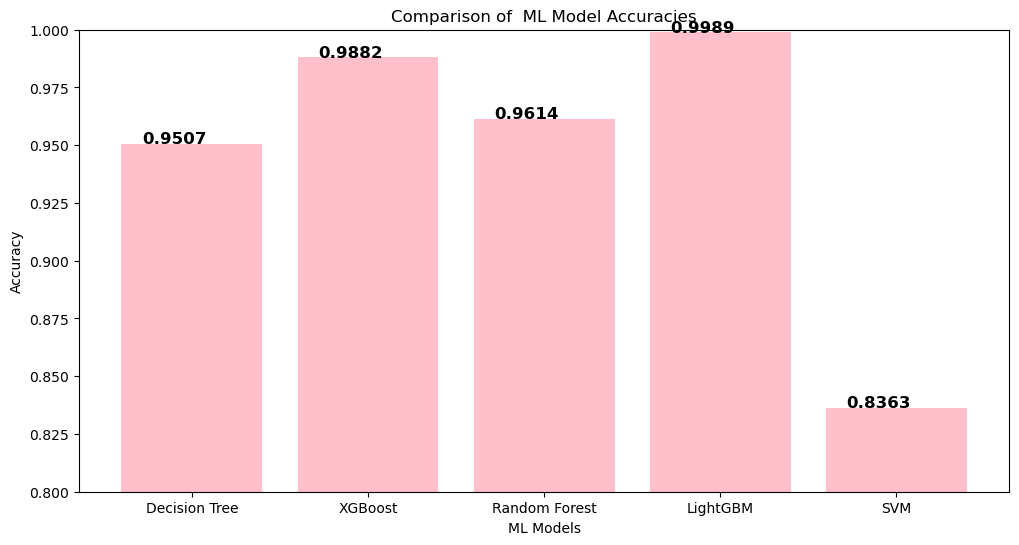

In [76]:
import matplotlib.pyplot as plt

# Model names
models = ["Decision Tree", "XGBoost", "Random Forest", "LightGBM","SVM"]

# Corresponding accuracy values (replace with actual values)
accuracies = [dt_accuracy, xgb_accuracy, rf_accuracy, lgbm_accuracy,accuracy]

# Create the bar chart
plt.figure(figsize=(12, 6))
bars = plt.bar(models, accuracies, color=['pink', 'pink', 'pink', 'pink','pink'])

# Display accuracy values on top of each bar
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2 - 0.1, bar.get_height(), 
             f"{bar.get_height():.4f}", ha='center', fontsize=12, fontweight='bold')

# Labels and title
plt.xlabel("ML Models")
plt.ylabel("Accuracy")
plt.title("Comparison of  ML Model Accuracies")
plt.ylim(0.8, 1)  # Assuming accuracy is between 0 and 1 (0% to 100%)

# Show the plot
plt.show()


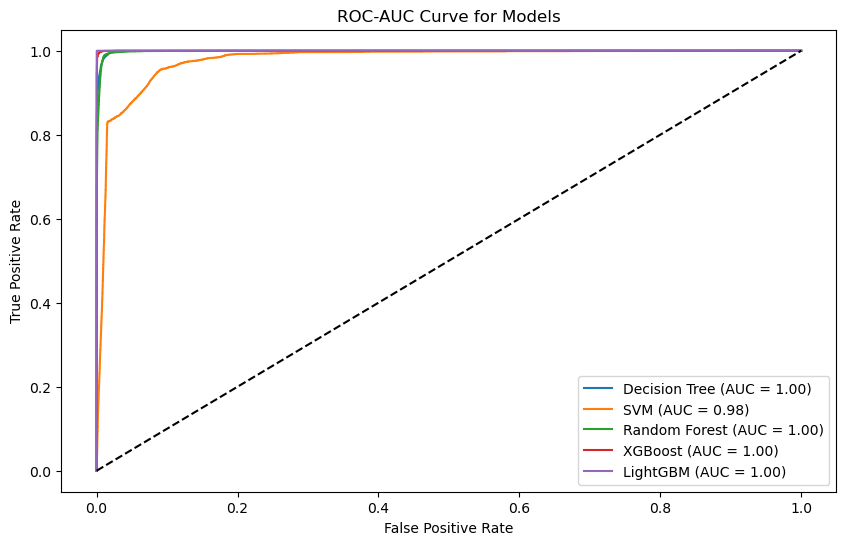

TypeError: print_accuracy() missing 1 required positional argument: 'y_pred'

In [80]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, accuracy_score, roc_auc_score
from sklearn.preprocessing import label_binarize

# Binarize the labels for multi-class support
y_test_binarized = label_binarize(y_test, classes=np.unique(y_test))
n_classes = y_test.shape[0]

# Get probability scores where applicable
y_probs_dt = dt_model.predict_proba(X_test_selected)
y_probs_svm = svm_model.decision_function(X_test_scaled) if hasattr(svm_model, "decision_function") else svm_model.predict_proba(X_test_scaled)
y_probs_rf = rf_model.predict_proba(X_test_selected)
y_probs_xgb = xgb_model.predict_proba(X_test_selected)
y_probs_lgbm = lgbm_model.predict_proba(X_test_selected)

# Define models and their probability outputs
models = {
    'Decision Tree': y_probs_dt,
    'SVM': y_probs_svm,
    'Random Forest': y_probs_rf,
    'XGBoost': y_probs_xgb,
    'LightGBM': y_probs_lgbm
}

# Convert y_test into a binary format for multi-class ROC-AUC
n_classes = len(np.unique(y_test))
y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))

# Plot ROC-AUC curve
plt.figure(figsize=(10, 6))
for name, y_probs in models.items():
    if n_classes > 2:
        # Compute AUC-ROC for multi-class
        y_probs = np.array(y_probs)
        if len(y_probs.shape) == 1:
            y_probs = np.expand_dims(y_probs, axis=1)
        fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_probs.ravel())
        roc_auc = auc(fpr, tpr)
    else:
        fpr, tpr, _ = roc_curve(y_test, y_probs)
        roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

# Plot settings
plt.plot([0, 1], [0, 1], 'k--')  # Random classifier line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve for Models')
plt.legend()
plt.show()

# Print Accuracy for all models
def print_accuracy(name, y_true, y_pred):
    accuracy = accuracy_score(y_test, y_test_pred_dt)
    print(f"{name} Model Accuracy: {accuracy:.4f}")

print_accuracy("Decision Tree", y_test_pred_dt)
print_accuracy("SVM", y_test_pred_svm)
print_accuracy("Random Forest", y_test_pred_rf)
print_accuracy("XGBoost", y_test_pred_xgb)
print_accuracy("LightGBM", y_test_pred_lgbm)

# Compute and print ROC-AUC for all models
print("\nROC-AUC Scores:")
for name, y_probs in models.items():
    if len(np.unique(y_test)) > 2:
        roc_auc = roc_auc_score(y_test_bin, y_probs, multi_class='ovr')  # Multi-class case
    else:
        roc_auc = roc_auc_score(y_test, y_probs)
    print(f"{name} Model AUC: {roc_auc:.4f}")


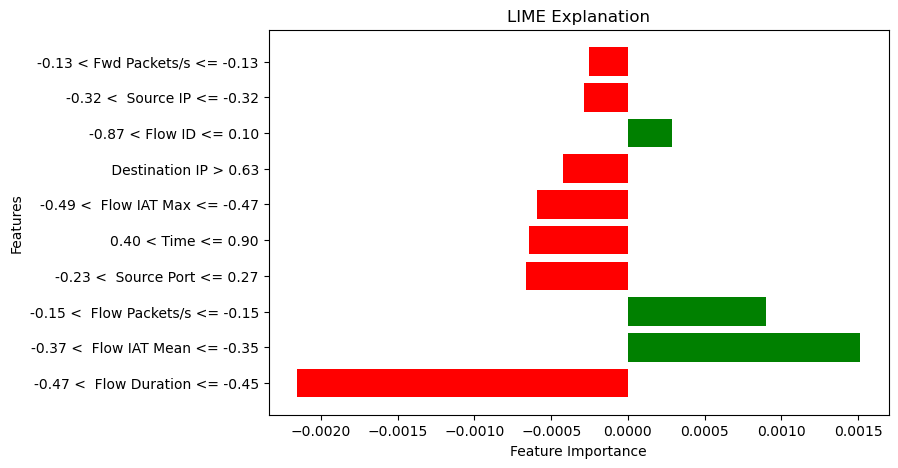

In [88]:
# Install LIME if not already installed
!pip install lime

import numpy as np
import lime
import lime.lime_tabular
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Use your pre-trained models
models = {
    "Decision Tree": dt_model,
    "SVM": svm_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
    "LightGBM": lgbm_model
}

# Standardize features (for SVM & other models)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled = scaler.transform(X_test_selected)

# Initialize LIME Explainer with fewer samples for speed
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_scaled,
    feature_names=X_train_selected.columns.tolist(),  # Ensure correct feature names
    class_names=[str(cls) for cls in np.unique(y_train)],
    mode="classification",
    discretize_continuous=True,  # Avoid excessive computation
    sample_around_instance=True  # Speeds up local explanation
)

# Select a test sample (you can change idx)
idx = 5  
X_instance = X_test_scaled[idx]

# Choose a model for explanation (Change this as needed)
selected_model_name = "Random Forest"  # Try "Decision Tree", "SVM", etc.
selected_model = models[selected_model_name]

# Generate explanation (reduce num_samples for faster computation)
exp = explainer.explain_instance(
    X_instance, 
    selected_model.predict_proba,
    num_samples=1000  # Default is 5000, reducing for speed
)

# Extract explanation values
lime_exp = exp.as_list()
features, weights = zip(*lime_exp)

# Assign colors based on impact (positive: green, negative: red)
colors = ["green" if w > 0 else "red" for w in weights]

# Plot LIME Explanation as a Bar Chart
plt.figure(figsize=(8, 5))
plt.barh(features, weights, color=colors)
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title(f"LIME Explanation")
plt.show()


In [86]:
# Train model
model = RandomForestClassifier()
model.fit(X_train, y_train)

# LIME Explanation
explainer = lime.lime_tabular.LimeTabularExplainer(X_train.values, feature_names=X.columns, class_names=["Bengin", "Ransomware"], discretize_continuous=True)
idx = 0  # Choose an instance
exp = explainer.explain_instance(X_test.iloc[idx].values, model.predict_proba, num_features=5)
exp.show_in_notebook()